# Evaluation and Visualization of Segmented Linear Regression

---

# Import Libraries

In [1]:
import sys
import os
root = os.path.abspath('..')  
sys.path.append(root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from piecewise_regression import r_squared_calc


from modules import load, plots, analysis, utils

# styles
plt.style.use('seaborn-v0_8-white')

---

## Parameters

In [4]:
# FILE_NAME: Name of the input CSV file containing raw profile measurements (e.g., depth vs conductivity).
ID_PROFILE_NAME = 'LRS70_D_YSI_R_20250226_processed'
# INPUT_DIR: Folder (relative to project root) where input files are located.
INPUT_DIR_JSON = os.path.join(root, 'data', 'results')

INPUT_DIR_PROCESSED = os.path.join(root, 'data', 'rawdy/rawdy_sat51w2p_priority')
# FILE_PATH: Full path to the input file. If you set this explicitly, it takes precedence over INPUT_DIR/FILE_NAME.
FILE_PATH_JSON = os.path.join(INPUT_DIR_JSON, ID_PROFILE_NAME + '_bic.json')

FILE_PROCESSED_PATH = os.path.join(INPUT_DIR_PROCESSED, ID_PROFILE_NAME + '.csv')

CALCULATE_OPTIMAL_TRIAL = True

TRIAL = '1'

N_BREAKPOINT = 3

# Column names in the input CSV (edit these if your file headers differ)
VP_NAME = 'Vertical Position m'           # independent variable (x)
SEC_NAME = 'Corrected sp Cond [µS/cm]'      # dependent variable (y)


---

## Load data

In [5]:
df_json_bic = pd.read_json(FILE_PATH_JSON)
df_json_bic

,trial_1,trial_2,trial_3
df,"{'bic': {'0': 18502.9630177174, '1': 18197.410...","{'bic': {'0': 18502.9630177174, '1': 18197.410...","{'bic': {'0': 18502.9630177174, '1': 18197.410..."
best_n_breakpoint_bic,3,3,3
min_bic_n_breakpoint,10,8,8
best_n_breakpoint_rss,2,2,2


In [6]:
# Prefer FILE_PATH if set; otherwise, compose from INPUT_DIR and FILE_NAME
csv_path = FILE_PROCESSED_PATH if os.path.isabs(FILE_PROCESSED_PATH) or FILE_PROCESSED_PATH else os.path.join(INPUT_DIR_PROCESSED, ID_PROFILE_NAME + '_rowdy_processed.csv')
print(f"Reading data from: {csv_path}")
df_processed = pd.read_csv(csv_path)

# Extract vectors
x_processed = df_processed[VP_NAME].to_numpy()
y_processed = df_processed[SEC_NAME].to_numpy()

df_processed.head()

Reading data from: c:\Users\Mariana\Documents\freshwater_lens\data\rawdy/rawdy_sat51w2p_priority\LRS70_D_YSI_R_20250226_processed.csv


,Vertical Position m,Corrected sp Cond [µS/cm]
0,0.282,3321.587008
1,0.310,3350.422707
2,0.338,3378.983863
3,0.366,3407.270475
4,0.394,3435.282543


---

### Calculate optimal `n_breakpoint`

In [7]:
if CALCULATE_OPTIMAL_TRIAL:
    trial = analysis.select_best_trial(FILE_PATH_JSON)
    trial_select = df_json_bic[trial[0]]
    #N_BREAKPOINT = df.loc['best_n_breakpoint_bic'].mode().iloc[0] # alternative, select 'best_n_breakpoint_rss'
else:
    trial_select = df_json_bic[f'trial_{TRIAL}']

In [8]:
# Elbow plot

x_values = np.array(list(trial_select['df']['n_breakpoints'].values()))
y_values = np.array(list(trial_select['df']['bic'].values()))
secondary_x = np.array(list(trial_select['df']['n_breakpoints'].values()))
secondary_y = np.array(list(trial_select['df']['rss'].values()))

plots.plot_data(
    x_values=x_values,
    y_values=y_values,
    plot_mode='lines+markers',
    x_axis_label="Number Breakpoints",
    y_axis_label="BIC",
    secondary_x=secondary_x,
    secondary_y=secondary_y,
    use_secondary_axis=True,
    y2_axis_label="RSS",
    trace_names=['BIC', 'RSS'],
    title=f"Elbow Plot: <b>{ID_PROFILE_NAME}<b>",
)

---

### Evaluation

In [9]:
# Params
params_ms = utils.get_breakpoint_data(trial_select['df'], N_BREAKPOINT)
params_ms

{'bic': 12412.4294207179,
 'n_breakpoints': 3,
 'estimates': {'const': {'estimate': 3706.1013164878,
   'se': 50.2493470845,
   'confidence_interval': [3607.4950589179, 3804.7075740577],
   't_stat': 73.7542183435,
   'p_t': 0.0},
  'beta1': {'estimate': 5003.4739629526,
   'se': 58.4887080879,
   'confidence_interval': [4888.6992852846, 5118.2486406207],
   't_stat': 85.5459818916,
   'p_t': '-'},
  'breakpoint1': {'estimate': 10.458731126,
   'se': 0.0209004721,
   'confidence_interval': [10.4177173127, 10.4997449392],
   't_stat': '-',
   'p_t': '-'},
  'beta2': {'estimate': 25509.4442652897,
   'se': 270.4474987981,
   'confidence_interval': [24978.7345690863, 26040.153961493],
   't_stat': 94.3230918335,
   'p_t': '-'},
  'breakpoint2': {'estimate': 13.2265492902,
   'se': 0.007073175100000001,
   'confidence_interval': [13.2126693222, 13.2404292581],
   't_stat': '-',
   'p_t': '-'},
  'beta3': {'estimate': -30532.942180858,
   'se': 264.2215999281,
   'confidence_interval': [-31

In [10]:
# Model Select
ms = utils.rebuild_model(x_processed,y_processed,params_ms)
ms

In [11]:
# Globals
RSS, TSS, R2, R2_ajus = r_squared_calc.get_r_squared(y_processed, 
                                                    ms.predict(x_processed), 
                                                    len(ms.get_params()))


print("RSS: ", RSS)
print("TSS: ", TSS)
print("R2: ", R2)
print("R2_ajus: ", R2_ajus)

RSS:  212564245.13931844
TSS:  536351964310.2942
R2:  0.999603685155861
R2_ajus:  0.9995989054793487


In [12]:
# Per segment
metric_per_segment = analysis.calculate_metrics_per_segment(ms)
metric_per_segment

[{'Segment': 1,
  'R^2': np.float64(0.8071508206607447),
  'RMS%': np.float64(6.293709218533898),
  'RMS% (min-max)': np.float64(8.034441917582397)},
 {'Segment': 2,
  'R^2': np.float64(0.967560693135782),
  'RMS%': np.float64(6.3619364165646095),
  'RMS% (min-max)': np.float64(5.183441259227055)},
 {'Segment': 3,
  'R^2': np.float64(0.9763384145454489),
  'RMS%': np.float64(4.197875314193559),
  'RMS% (min-max)': np.float64(5.404972052082399)},
 {'Segment': 4,
  'R^2': np.float64(0.9292018550458127),
  'RMS%': np.float64(0.4946051740914357),
  'RMS% (min-max)': np.float64(6.690542107859206)}]

In [13]:
# Breakpoints
breakpoints = analysis.extract_breakpoints(ms)
breakpoints

,Breakpoint X Position,Breakpoint Y Position,Confidence Interval (X)
1,10.458731,6351.062960,"(10.417717312667767, 10.499744939240935)"
2,13.226549,20899.736675,"(13.212669322178671, 13.2404292581309)"
3,14.228627,51729.485756,"(14.218564496635341, 14.23869037058213)"


##

---

### Final results

#### General models

In [14]:
# Visualizamos los datos procesados junto con los modelos obtenidos
df_ms = pd.DataFrame({'n_breakpoints': trial_select['df']['n_breakpoints'], 
                    'estimates': trial_select['df']['estimates']})

plots.interactive_segmented_regression(x=x_processed, 
                                       y=y_processed, 
                                       df=df_ms, 
                                       title=f"{ID_PROFILE_NAME}",
                                       breakpoints=N_BREAKPOINT)

interactive(children=(IntSlider(value=3, description='n_breakpoints', max=10), Output()), _dom_classes=('widge…

#### Models per segment

In [15]:
segments = utils.extract_segments(ms)   
segments

{'segments': [{'segment': 1,
   'data_x': array([ 0.282,  0.31 ,  0.338,  0.366,  0.394,  0.422,  0.45 ,  0.478,
           0.506,  0.534,  0.562,  0.59 ,  0.618,  0.646,  0.674,  0.702,
           0.73 ,  0.758,  0.786,  0.814,  0.842,  0.87 ,  0.898,  0.926,
           0.954,  0.982,  1.01 ,  1.038,  1.066,  1.094,  1.122,  1.15 ,
           1.178,  1.206,  1.234,  1.262,  1.29 ,  1.318,  1.346,  1.374,
           1.402,  1.43 ,  1.458,  1.486,  1.514,  1.542,  1.57 ,  1.598,
           1.626,  1.654,  1.682,  1.71 ,  1.738,  1.766,  1.794,  1.822,
           1.85 ,  1.878,  1.906,  1.934,  1.962,  1.99 ,  2.018,  2.046,
           2.074,  2.102,  2.13 ,  2.158,  2.186,  2.214,  2.242,  2.27 ,
           2.298,  2.326,  2.354,  2.382,  2.41 ,  2.438,  2.466,  2.494,
           2.522,  2.55 ,  2.578,  2.606,  2.634,  2.662,  2.69 ,  2.718,
           2.746,  2.774,  2.802,  2.83 ,  2.858,  2.886,  2.914,  2.942,
           2.97 ,  2.998,  3.026,  3.054,  3.082,  3.11 ,  3.138,  3.166,

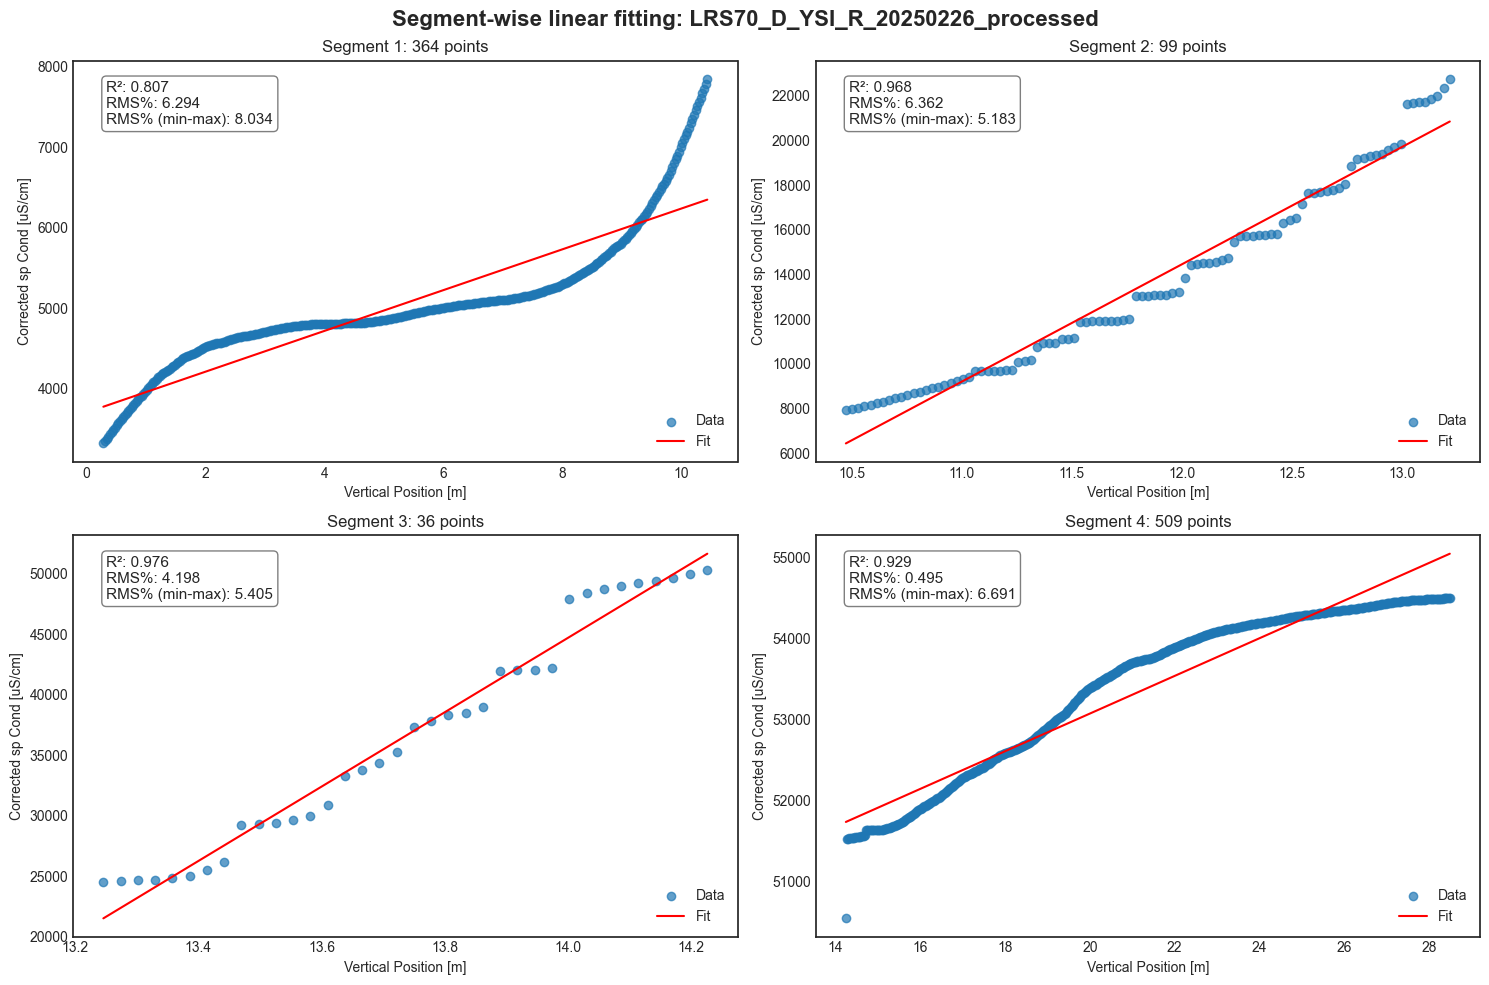

In [16]:
plots.plot_segments(segments, 
                    metric_per_segment, 
                    title=f"Segment-wise linear fitting: {ID_PROFILE_NAME}")

---

## Other analysis

### 1. Density of points in processed data


In [17]:
width = 1 # meters

density = analysis.calculate_density(x_processed, y_processed, bin_width=width)

In [18]:
# Plot data density
plots.plot_histogram(density,
            value_column='x_bin', 
            weight_column='frequency', 
            num_bins=len(density['x_bin']),
            title=f'Data density histogram (bin width = {width} m) | <b>{ID_PROFILE_NAME}<b>',
            x_axis_title='Vertical Position [m]',
            bar_color='lightgreen'
            ) 